## `bias_photometric`
---------------------

This notebook is used for the appendix plot to deal with the bias correction on the photometric sample with tomographic bins $\Delta z=0.1$.
Credit to the original script of this notebook should be attributed to William d'Assises Doumerg; the notebook has been adapted to use the distributions used in this analysis.

In [153]:
import pyccl as ccl
import matplotlib.pyplot as plt
import numpy as np

from scipy import interpolate
from scipy.stats import norm
from pathlib import Path

import src.analysis.plots as plots
import src.statistics.inference as inference
import src.statistics.corrfiles as cf
import src.statistics.cosmotools as ct

PAPER_FIGURES_ROOT = Path('/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/paper/figures/')
pm = plots.PlotManager(root=PAPER_FIGURES_ROOT, overwrite=True)

# 0- $\omega_{dm}$ Correlation

$\xi_{dm}(\theta,z)=\frac{H_0}{c}\frac{1}{\chi^2(z)}\sum_\ell \frac{2\ell+1}{4\pi} P_{\delta}(k=\frac{l+1/2}{\chi(z)},z) \mathcal{P}_{l}(\cos \theta)$

Then:
$\omega_{dm}(z)=\int d\theta W(\theta) \xi_{dm}(\theta,z)$. 

We procceed as follow:
- we generate the list $\{\ell\}$
-  we compute the associated angular power spectrum $P(k(l),z)$
- we use the correlation.correlation module to evaluate $\sum_{\ell}...$ given our power spectrum model
- we integrate it for our min-max projected scales (converted to angle) to have $\omega_{dm}$


### We use the $r_p$ scale convention

In [27]:
ROOT = Path('/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/src/statistics/')
stem = 'outputs/calibration'
path_dictionary = {
    'dr1' : {
        'HSC' : ROOT / stem / f'autos_HSC',
        'DESI_NGC' : ROOT / stem / 'dr1' / f'autos_NGC',
        'DESI_SGC' : ROOT / stem / 'dr1' /f'autos_SGC',
        'DESIxHSC' : ROOT / stem / 'dr1' / f'cross',
    },
    'dr2' : {
        'HSC' : ROOT / stem / f'autos_HSC',
        'DESI_NGC' : ROOT / stem / 'dr2' / f'autos_NGC',
        'DESI_SGC' : ROOT / stem / 'dr2' /f'autos_SGC',
        'DESIxHSC' : ROOT / stem / 'dr2' / f'cross',
    }
}
assert all([pv.exists() for p in path_dictionary.values() for pv in p.values()])

scale_cut = [0.3, 3]
correction_file_reader = cf.CorrFileReader(path_dictionary["dr2"]["HSC"])
rp_wdm = np.linspace(scale_cut[0], scale_cut[1], 100)

data_galbias = np.load(ROOT / f'results/photoz_bias_splines_v3_dz005_sc_{scale_cut[0]}_{scale_cut[1]}/tomo_photoz.npz')
correction_file_reader = cf.CorrFileReader(path_dictionary["dr2"]["HSC"])
bins_z_photo = inference._get_fine_redshift_bins(
    fr=correction_file_reader,
    tracer='HSC'
)
vals_z_photo = (bins_z_photo[:-1] + bins_z_photo[1:]) / 2
nz_bins = []
zlim = 1.6 # truncate useful bins to 1.6
vals_z_photo = vals_z_photo[vals_z_photo < zlim]

zv = np.linspace(0.005, 2.5, 500)
for i in range(len(vals_z_photo)):
    redshifts = data_galbias[f'{i+1}/redshifts']
    nz_med = data_galbias[f'{i+1}/nz_median']
    normal = np.trapezoid(nz_med, x=redshifts)

    nz_med_interp = np.interp(zv, redshifts, nz_med / normal, left=0, right=0)
    nz_bins.append(nz_med_interp)

In [28]:
w_dm_values = [ct.w_dm(
        rp_vals = rp_wdm,
        z = z,
        integrate = True
    ) for z in np.linspace(0.005, 3, 100)
]
wm = interpolate.interp1d(
    x = np.linspace(0.005, 3, 100),
    y = w_dm_values
)
wm_v=wm(zv)

## 1) Introduce n(z) and bias
----------------------------


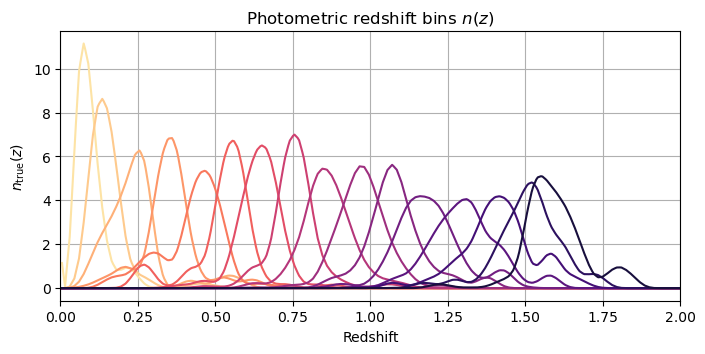

In [33]:
plt.figure(figsize=(8,3.5))
cmap = plt.get_cmap('magma_r')
for i in range(len(nz_bins)):
    plt.plot(zv, nz_bins[i], color=cmap((i+1) / (len(nz_bins)+2)))
plt.title(r'Photometric redshift bins $n(z)$')
plt.ylabel(r'$n_{\rm true}(z)$')
plt.xlabel(r'Redshift')
plt.xlim(0, 2)
plt.grid()

Text(0.5, 0, 'Redshift')

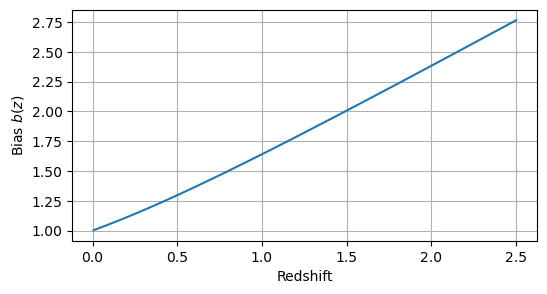

In [146]:
# we use a 1/D(z) bias model computed with ccl.
bias = 1 / ccl.background.growth_factor(cosmo=ct.COSMO_ccl, a=1/(1+zv))
plt.figure(dpi=100, figsize=(6, 3))
plt.grid()
plt.plot(zv, bias)
plt.ylabel(r'Bias $b(z)$')
plt.xlabel(r'Redshift')

# 2 - Compute $n_{pk}$

In [147]:
dz = zv[1] - zv[0]
# what we assume to be the truth
nz_bins = np.array(nz_bins)

# what is measured
npk_bins = (nz_bins * (bias[None, :] * np.sqrt(wm_v))) / (np.sum(nz_bins * (bias[None, :] * np.sqrt(wm_v)), axis=1, keepdims=True) * dz)

means_npk = np.sum(zv[None, :] * npk_bins * dz, axis=1)

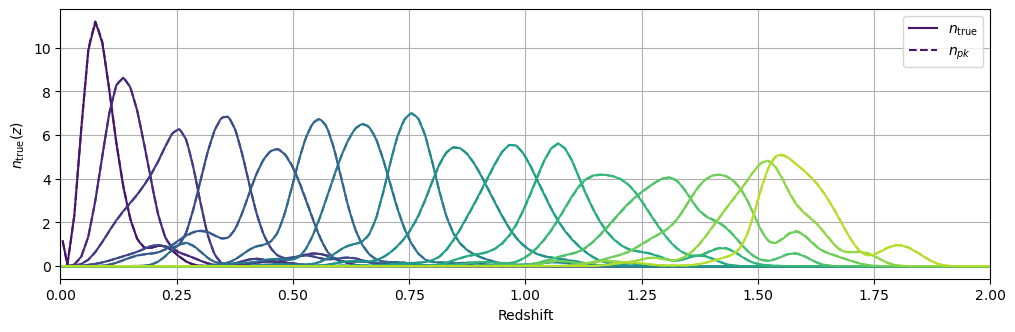

In [150]:
plt.figure(figsize=(12, 3.5))
cmap = plt.get_cmap('viridis')

for i in range(len(nz_bins)):
    plt.plot(zv, nz_bins[i], label=r'$n_{\rm true}$' if i==0 else None, color=cmap((i+1) / (len(nz_bins)+2)))
    plt.plot(zv, npk_bins[i], linestyle='--', label=r'$n_{pk}$' if i==0 else None, color=cmap((i+1) / (len(npk_bins)+2)))
plt.grid()
plt.ylabel(r'$n_{\rm true}(z)$')
plt.xlabel(r'Redshift')
plt.xlim(0.0, 2)
plt.legend()

# 3- Compute $w_{pp}$ measured

In [151]:
wpp_measured = np.sum((bias[None, :] * nz_bins)**2 * wm_v[None, :] * dz, axis=1)

Text(0.5, 0, 'Redshift')

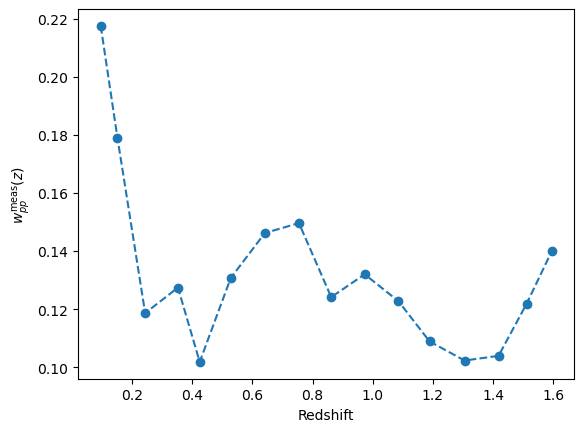

In [152]:
plt.figure(dpi=100)
plt.plot(means_npk, wpp_measured, marker='o',linestyle='--')

plt.ylabel(r'$w_{pp}^{\rm meas}(z)$')
plt.xlabel(r'Redshift')

# 4- Compare the bias from the correction vs the true bias
$b_{eff}^2=w_{pp}^{meas}/\int dz\, n_{pk}^2*w_m$

In [143]:
integ = np.sum(npk_bins**2 * wm_v[None, :], axis=1) * dz
bias_corrected = np.sqrt(wpp_measured / integ)

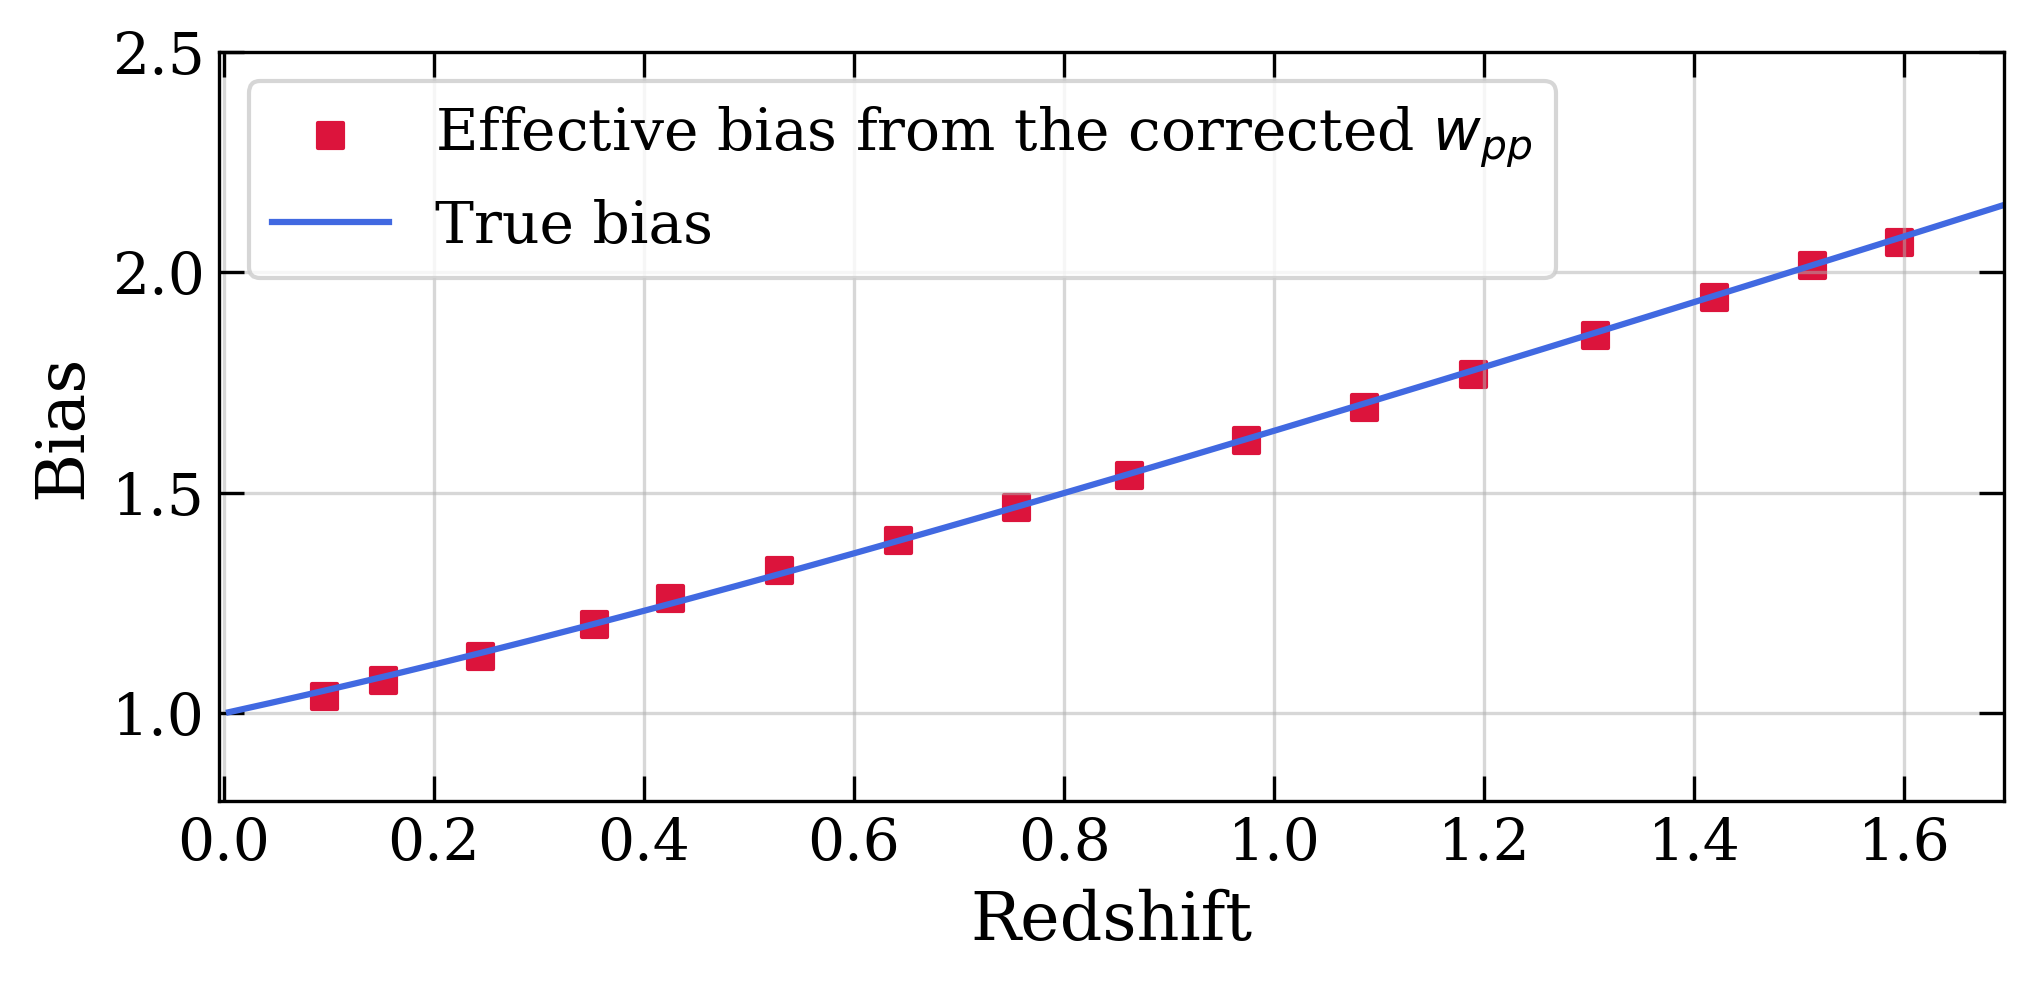

In [157]:
with pm.make_plot(name='bias_correction', figsize=(7, 3.5), show=True) as (fig, ax):
    ax.scatter(means_npk, bias_corrected, color='crimson', marker='s', label='Effective bias from the corrected $w_{pp}$')
    ax.plot(zv, bias, color='royalblue', label='True bias')
    ax.legend(loc='upper left')
    ax.set_xlabel('Redshift')
    ax.set_ylabel('Bias')
    ax.set_xlim(means_npk[0]-0.1, means_npk[-1]+0.1)
    ax.grid(True)
    ax.set_ylim(0.8, 2.5)

The max deviation is at the  1.1 % level, this is fine


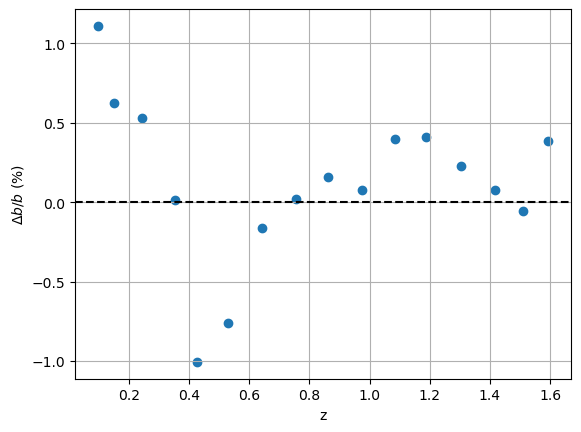

In [145]:
bias_disc = interpolate.interp1d(zv, bias)(means_npk)
plt.scatter(means_npk, (bias_disc - bias_corrected) / bias_disc * 100)
plt.ylabel(r'$\Delta b/b$' + ' (%)')
plt.grid()
plt.axhline(0, color='black', linestyle='--', alpha=1)
plt.xlabel(r'z')
print('The max deviation is at the ', round(max(abs((bias_disc - bias_corrected) / bias_disc)) * 100, 1), '% level, this is fine')

In [ ]:
# explanatory plot
